<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/%20Chapter-4-Nonholonomic-Mechanics/Untitled163.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Two Wheel Cart**

**Implementation using a  soft-constraint approach**

Epoch     0 | L_total=3.992203e+01 | L_energy=6.169776e+00 | L_constr=1.725642e+00 | L_hol=3.202661e+00
Epoch   500 | L_total=1.593506e+01 | L_energy=7.097244e+00 | L_constr=1.751651e+00 | L_hol=7.086161e-01
Epoch  1000 | L_total=1.239688e+01 | L_energy=7.429825e+00 | L_constr=1.300528e+00 | L_hol=3.666530e-01
Epoch  1500 | L_total=1.143685e+01 | L_energy=7.437257e+00 | L_constr=1.226199e+00 | L_hol=2.773397e-01
Epoch  2000 | L_total=1.098490e+01 | L_energy=7.452606e+00 | L_constr=1.190111e+00 | L_hol=2.342184e-01
Epoch  2500 | L_total=1.069762e+01 | L_energy=7.457386e+00 | L_constr=1.172606e+00 | L_hol=2.067633e-01
Epoch  3000 | L_total=1.049563e+01 | L_energy=7.465812e+00 | L_constr=1.161414e+00 | L_hol=1.868404e-01
Epoch  3500 | L_total=1.033952e+01 | L_energy=7.473138e+00 | L_constr=1.153520e+00 | L_hol=1.712862e-01
Epoch  4000 | L_total=1.021515e+01 | L_energy=7.478237e+00 | L_constr=1.147541e+00 | L_hol=1.589369e-01
Epoch  4500 | L_total=1.011248e+01 | L_energy=7.483662e+00 | L_c

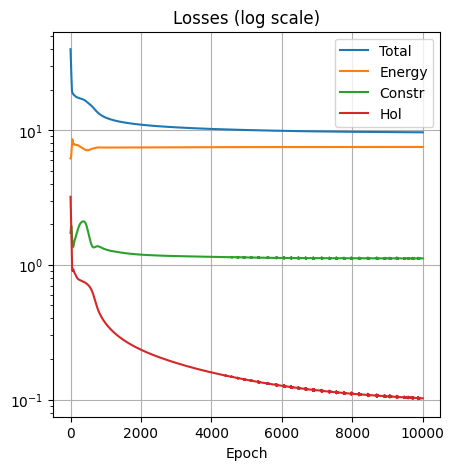

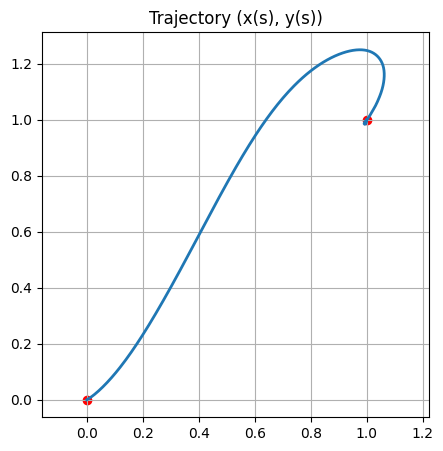

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# =============================
# PARAMETERS
# =============================
L = 1.0
R = 1.0
mu = 10.0

epochs = 10000
lr = 1e-3
N = 600

# boundary conditions
x0, y0, psi0, phi10, phi20 = 0., 0., 0., 0., 0.
x1, y1, psi1, phi11, phi21 = 1., 1., np.pi/2, np.pi/2, np.pi

C0 = psi0 - (R/L)*(phi10 - phi20)

# =============================
# NETWORK
# =============================
class Net(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.hidden = [
            tf.keras.layers.Dense(64, activation='tanh'),
            tf.keras.layers.Dense(64, activation='tanh')
        ]
        self.out = tf.keras.layers.Dense(5)

    def call(self, t):
        z = t
        for layer in self.hidden:
            z = layer(z)
        return self.out(z)

net = Net()

# =============================
# HARD-EMBEDDED OUTPUT
# =============================
def model_outputs(t):
    nn = net(t)

    x = (1-t)*x0 + t*x1 + t*(1-t)*nn[:,0:1]
    y = (1-t)*y0 + t*y1 + t*(1-t)*nn[:,1:2]
    psi = (1-t)*psi0 + t*psi1 + t*(1-t)*nn[:,2:3]
    phi1 = (1-t)*phi10 + t*phi11 + t*(1-t)*nn[:,3:4]
    phi2 = (1-t)*phi20 + t*phi21 + t*(1-t)*nn[:,4:5]

    return x, y, psi, phi1, phi2

# =============================
# LOSS FUNCTION
# =============================
def compute_losses(t):
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(t)
        x, y, psi, phi1, phi2 = model_outputs(t)

    dx = tape.gradient(x, t)
    dy = tape.gradient(y, t)
    dphi1 = tape.gradient(phi1, t)
    dphi2 = tape.gradient(phi2, t)

    # Energy
    L_energy = tf.reduce_mean(0.5*(dphi1**2 + dphi2**2))

    # Nonholonomic
    constr1 = dx - (R/2.0)*tf.cos(psi)*(dphi1 + dphi2)
    constr2 = dy - (R/2.0)*tf.sin(psi)*(dphi1 + dphi2)
    L_constr = tf.reduce_mean(constr1**2 + constr2**2)

    # Holonomic
    hol = psi - (R/L)*(phi1 - phi2) - C0
    L_hol = tf.reduce_mean(hol**2)

    # Total
    L_total = L_energy + L_constr + mu*L_hol

    return L_energy, L_constr, L_hol, L_total

# =============================
# TRAINING
# =============================
optimizer = tf.keras.optimizers.Adam(lr)

loss_hist = []
energy_hist = []
constr_hist = []
hol_hist = []

t_train = tf.linspace(0.0, 1.0, N)[:,None]

@tf.function
def train_step():
    with tf.GradientTape() as tape:
        Le, Lc, Lh, Lt = compute_losses(t_train)
    grads = tape.gradient(Lt, net.trainable_variables)
    optimizer.apply_gradients(zip(grads, net.trainable_variables))
    return Le, Lc, Lh, Lt

for ep in range(epochs):
    Le, Lc, Lh, Lt = train_step()

    loss_hist.append(Lt.numpy())
    energy_hist.append(Le.numpy())
    constr_hist.append(Lc.numpy())
    hol_hist.append(Lh.numpy())

    # ===== detailed print =====
    if ep % 500 == 0:
        print(f"Epoch {ep:5d} | "
              f"L_total={Lt.numpy():.6e} | "
              f"L_energy={Le.numpy():.6e} | "
              f"L_constr={Lc.numpy():.6e} | "
              f"L_hol={Lh.numpy():.6e}")

# =============================
# PLOTS: LOSSES (LOG SCALE)
# =============================
plt.figure(figsize=(5,5))
plt.plot(loss_hist, label='Total')
plt.plot(energy_hist, label='Energy')
plt.plot(constr_hist, label='Constr')
plt.plot(hol_hist, label='Hol')
plt.yscale('log')
plt.legend()
plt.title("Losses (log scale)")
plt.xlabel("Epoch")
plt.grid()
plt.show()

# =============================
# TRAJECTORY
# =============================
t_test = tf.linspace(0.0, 1.0, 300)[:,None]
x, y, _, _, _ = model_outputs(t_test)

plt.figure(figsize=(5,5))
plt.plot(x.numpy(), y.numpy(), linewidth=2)
plt.scatter([x0, x1], [y0, y1], color='red')
plt.title("Trajectory (x(s), y(s))")
plt.axis('equal')
plt.grid()
plt.show()